In [ ]:
# I generated this script to plot in ven diagrams the numbers of TFs predicted in Drososphila and Tribolium
# I also plotted the number of TFs found in the DE analyses and how this numbers compare to the dataset of Drosophila and tribolium NBs
# I included jaccard plot to see how robust my DE analyses were
#

In [ ]:
import pandas as pd
from supervenn import supervenn
import matplotlib.pyplot as plt
from matplotlib_venn import venn2
from matplotlib_venn import venn3
import seaborn as sns

In [2]:

def cerating_plots (file1= None, 
                    file2= None,
                    title= 'TFs Differentially expressed',
                    savefig= 'TF_supervenn_all_TFs_DE.pdf'):
    tribo_TF_found= file1 
    droso_TF_found= file2

    set_tribo = set(tribo_TF_found)
    set_droso = set(droso_TF_found)

    sets = [set_tribo, set_droso]
    set_annotations = ["Tribolium TFs", "Drosophila TFs"]

    # FIGURE WITH TWO SUBPLOTS
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    # Supervenn plot
    plt.sca(axes[0])
    supervenn(
        sets,
        set_annotations=set_annotations,
        widths_minmax_ratio=0.05)
    plt.title("Supervenn Diagram", fontsize=20)
    #  Euler/Venn plot 
    plt.sca(axes[1])
    venn2([set_tribo, set_droso],
        set_labels=["Tribolium", "Drosophila"],
        set_colors=("#5CFEBD", "#E956E2"),
        alpha=0.3)
    plt.title(title, fontsize=20)

    plt.tight_layout()
    plt.savefig(savefig, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

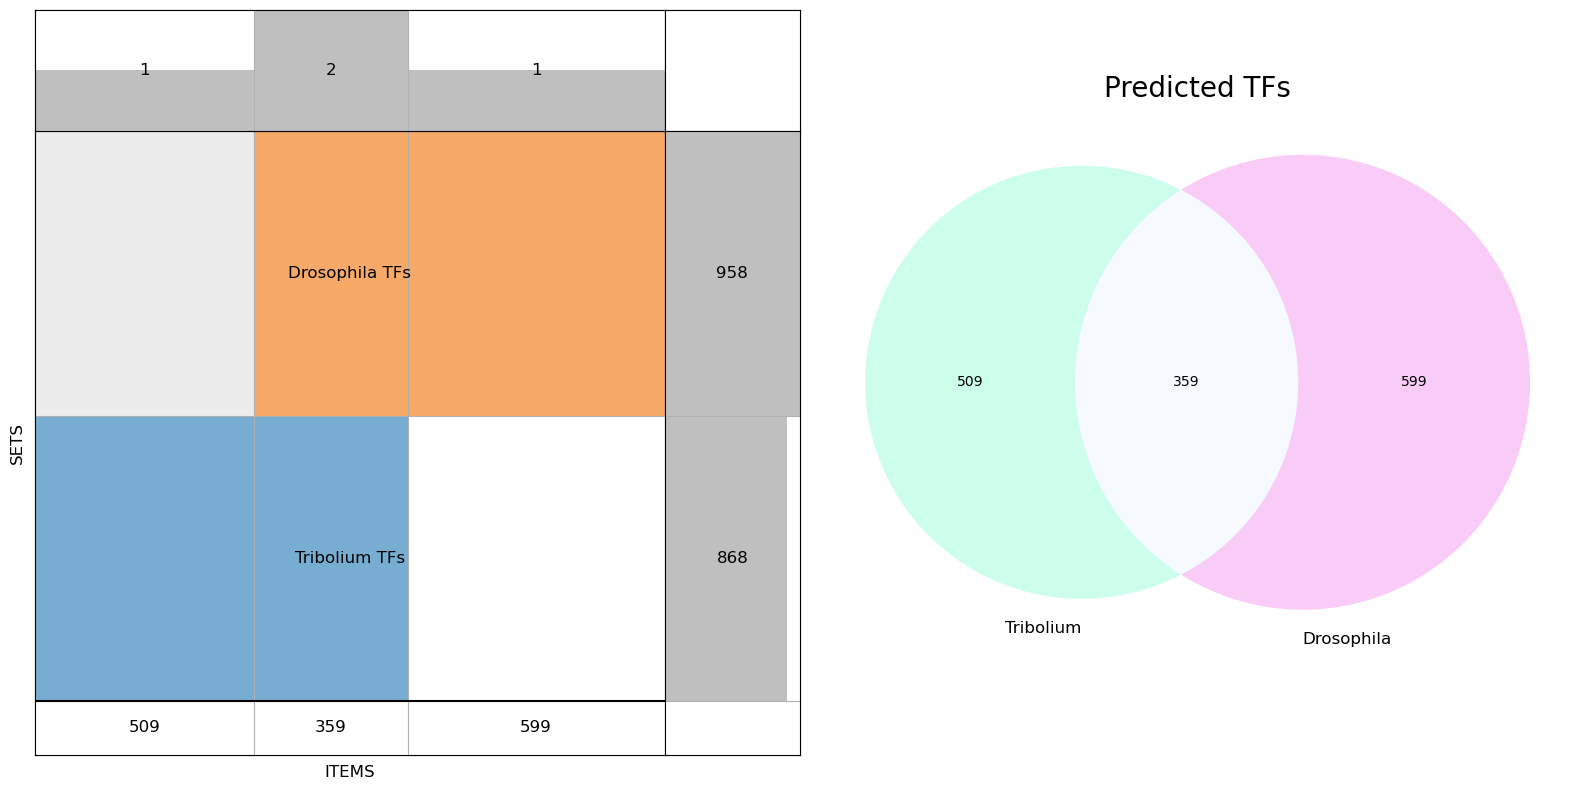

In [3]:
###this are the original list of TFs predicted
path_TFs= 'TF_predicted/'
droso_TF= pd.read_csv(f'{path_TFs}droso_output_true_annotated.csv', )
tribo_TF= pd.read_csv(f'{path_TFs}tribolium_output_true_annotated.csv', sep='\t',)

cerating_plots (file1= tribo_TF['gene_symbol'], 
                file2= droso_TF['gene_name'],
                title= 'Predicted TFs',
                savefig= 'TF_supervenn_Original_lists.pdf')

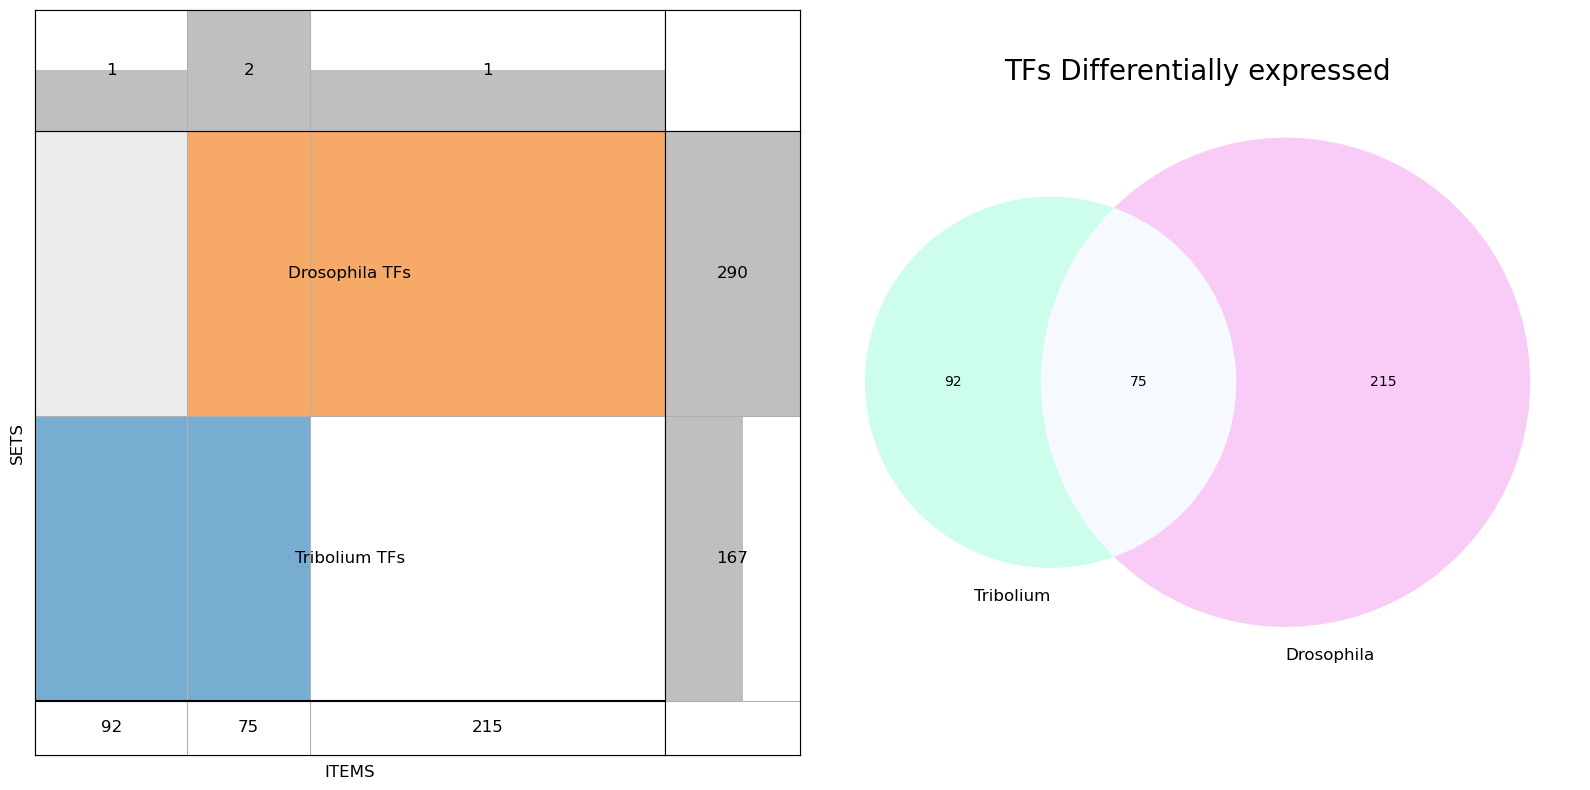

In [4]:
###this are all the TFs DE in  the neuroblasts datasets
path_TFs= 'TFS_found/'
droso_TF_found= pd.read_csv(f'{path_TFs}Drosophila/4_TFs_including_Hox_DE_ordered_as_inthe_heatmapplot_droso.csv')
tribo_TF_found= pd.read_csv(f'{path_TFs}Tribolium/4_TFs_including_Hox_DE_ordered_as_inthe_heatmapplot_tribolium.csv')

cerating_plots (file1= tribo_TF_found['gene_names'], 
                file2= droso_TF_found['gene_symbol'],
                title= 'TFs Differentially expressed',
                savefig= 'TF_supervenn_all_TFs_DE.pdf')

In [5]:
droso_TF_found

,gene_symbol,Nbs_type,Hox_1,Hox_2,Hox_7,Hox_4,Hox_9,Hox_6,Hox_10,Hox_3,...,No_hox_8,No_hox_2,No_hox_6,No_hox_5,No_hox_9,No_hox_3,No_hox_1,No_hox_10,No_hox_4,No_hox_7
0,vnd,VNC,5.130044,5.205384,5.186212,5.292143,5.223680,5.225040,5.114989,5.088656,...,5.199379,5.245055,5.232588,4.852244,4.878950,4.928358,4.894360,5.176240,5.007702,4.862764
1,CG6712,VNC,6.494586,6.498681,6.529010,6.518029,6.478769,6.515554,6.530735,6.480843,...,6.457838,6.409020,6.496087,6.419704,6.447990,6.447634,6.438244,6.472286,6.483579,6.590185
2,HGTX,VNC,5.520905,5.513245,5.328993,5.504300,5.421964,5.477238,5.479803,5.481450,...,5.525949,5.027654,5.286864,5.110736,5.215091,5.438802,5.348369,5.407871,5.349090,5.422898
3,pre-lola-G,VNC,3.854231,3.894771,3.868638,3.769021,3.835012,3.893872,3.808768,3.764539,...,3.800601,3.268140,3.714568,3.612223,3.552320,3.083436,3.580111,3.344355,3.555573,3.667845
4,eyg,VNC,3.695445,3.617657,3.263986,3.085520,3.198959,2.436369,3.287271,2.926106,...,2.079003,2.242921,3.476191,3.072649,2.788239,3.359602,1.829638,1.812653,2.604851,3.230344
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
285,btz,brain,5.360857,5.499444,5.466070,5.438458,5.419427,5.369917,5.327937,5.341720,...,5.461212,5.529192,5.575482,5.521081,5.487485,5.525451,5.529898,5.415500,5.406930,5.445613
286,CG12253,brain,5.700244,5.683013,5.744801,5.677246,5.700903,5.696144,5.638465,5.639065,...,5.850265,5.807482,5.772458,5.846537,5.777636,5.785830,5.847269,5.715296,5.750126,5.695968
287,CG30460,brain,4.033015,3.617657,3.832159,3.714005,3.550397,4.256224,3.565571,4.009214,...,4.695428,4.574683,4.153755,4.483521,4.490038,4.794065,4.499117,3.653139,4.065197,4.034528
288,TfIIS,brain,7.028795,7.059478,7.061392,7.023970,7.034954,7.040104,7.082539,7.005276,...,7.044622,7.068905,7.094821,7.141001,7.113117,7.058290,7.137544,6.990392,7.069165,7.085566


In [6]:
tribo_TF_found

,gene_names,Nbs_type,Hox_7,Hox_9,Hox_10,Hox_4,Hox_6,Hox_2,Hox_3,Hox_5,...,No_hox_3,No_hox_2,No_hox_10,No_hox_6,No_hox_4,No_hox_8,No_hox_5,No_hox_7,No_hox_1,No_hox_9
0,Ptx1,VNC,4.929506,5.084466,5.068790,5.004562,5.072347,5.177237,5.007180,5.093427,...,4.778061,4.862119,4.654194,5.197398,4.614266,4.771240,4.730919,5.340908,4.455517,4.830927
1,Lim3,VNC,5.614054,5.447061,5.447190,5.292932,5.423691,5.396715,5.443958,5.422832,...,5.114854,5.216471,5.309578,5.027281,4.822680,5.442202,5.006410,5.597156,4.994250,5.133320
2,yps,VNC,8.759463,8.779123,8.760193,8.719742,8.784343,8.784846,8.816786,8.779380,...,8.733879,8.782592,8.726738,8.673090,8.783746,8.715857,8.684186,8.739273,8.710195,8.757554
3,TC008064,VNC,5.505211,5.301341,5.429532,5.288194,5.571433,5.202224,5.517186,5.387386,...,5.167888,5.535453,5.191015,4.929975,5.037338,5.197276,5.222168,5.201865,4.978101,5.239333
4,tara,VNC,6.274063,6.299080,6.271198,6.259289,6.270484,6.276303,6.215742,6.260538,...,6.078160,6.347761,6.220653,6.152084,6.034671,6.114873,6.182743,6.089585,6.155744,6.311715
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
164,TC006580,brain,7.157925,7.194890,7.283612,7.318390,7.323909,7.242147,7.374913,7.378084,...,7.925338,7.636315,7.565263,7.719372,7.836263,7.645616,7.892121,7.450845,7.682974,7.478155
165,Xbp1,brain,6.008821,6.005382,6.047460,6.091274,5.906569,5.940920,6.004577,5.978793,...,6.200298,5.873093,6.150838,6.222654,6.108245,6.033088,6.130336,6.058405,6.066644,6.104201
166,ind,brain,4.675542,5.015319,4.854280,4.755162,4.685591,4.836942,4.828048,4.742215,...,5.141723,4.709256,4.866765,5.040440,5.091063,5.161970,4.928178,5.054822,4.760733,5.205229
167,fkh,brain,4.577333,4.690384,4.566850,4.549196,4.569487,4.578727,4.697769,4.414853,...,4.903357,4.550479,4.564128,5.115952,5.091063,4.658927,5.050571,5.176688,4.508973,4.880138


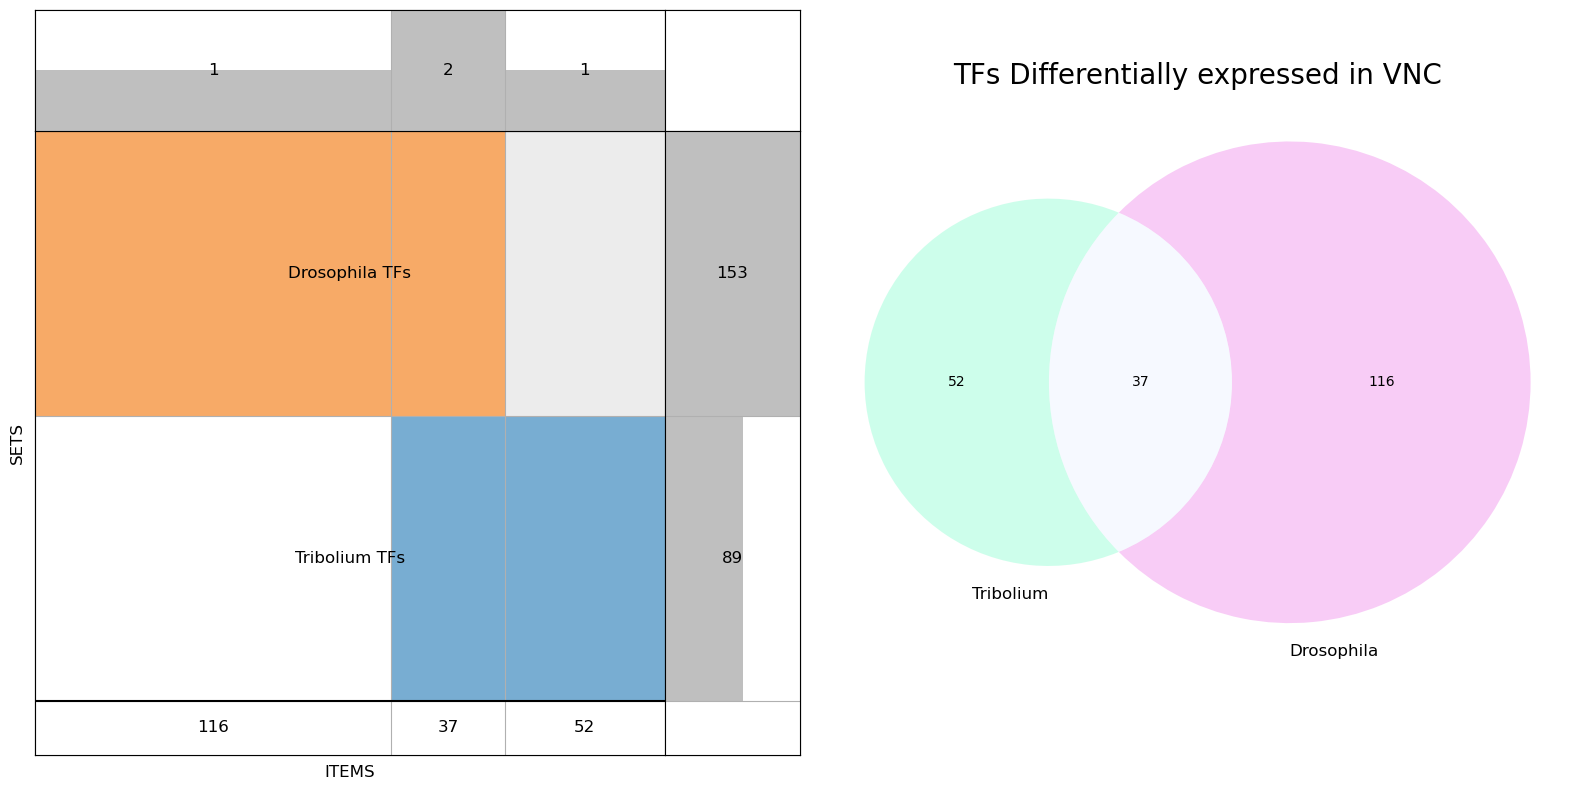

In [7]:
###this are all the TFs DE in  the VNC neuroblasts datasets
path_TFs= 'TFS_found/'
droso_TF_found= pd.read_csv(f'{path_TFs}Drosophila/4_TFs_including_Hox_DE_ordered_as_inthe_heatmapplot_droso.csv')
tribo_TF_found= pd.read_csv(f'{path_TFs}Tribolium/4_TFs_including_Hox_DE_ordered_as_inthe_heatmapplot_tribolium.csv')

file1=tribo_TF_found[tribo_TF_found['Nbs_type'] == 'VNC'] # i did manually based om the heatmap plot
file2=droso_TF_found[droso_TF_found['Nbs_type'] == 'VNC'] # i did manually based om the heatmap plot

cerating_plots (file1= file1['gene_names'], 
                file2= file2['gene_symbol'],
                title= 'TFs Differentially expressed in VNC',
                savefig= 'TF_supervenn_VNC_TFs_DE.pdf')

In [ ]:
def get_TF_lists(file1=None, file2=None):
    """
    Returns lists of shared and unique TFs between Tribolium and Drosophila VNC neuroblasts.
    
    Parameters:
        file1: Tribolium TF dataframe (filtered for VNC)
        file2: Drosophila TF dataframe (filtered for VNC)
    
    Returns:
        dict with keys:
            - 'shared_TFs'
            - 'tribo_only_TFs'
            - 'droso_only_TFs'
    """
    # Convert the 'TF_name' column to sets
    tribo_TFs = set(file1)
    droso_TFs = set(file2)
    
    # Compute shared and unique TFs
    shared_TFs = sorted(list(tribo_TFs & droso_TFs))
    tribo_only_TFs = sorted(list(tribo_TFs - droso_TFs))
    droso_only_TFs = sorted(list(droso_TFs - tribo_TFs))
    
    # Return as dictionary
    return {
        'shared_TFs': shared_TFs,
        'tribo_only_TFs': tribo_only_TFs,
        'droso_only_TFs': droso_only_TFs,
        'len_shared_TFs': len(shared_TFs),
        'len_tribo_only_TFs': len(tribo_only_TFs),
        'len_droso_only_TFs': len(droso_only_TFs)}


In [9]:
tf_lists = get_TF_lists(file1=file1['gene_names'], file2=file2['gene_symbol'])
print("Shared TFs:", tf_lists['len_shared_TFs'], tf_lists['shared_TFs'])
print("Tribolium only TFs:", tf_lists['len_tribo_only_TFs'], tf_lists['tribo_only_TFs'])
print("Drosophila only TFs:", tf_lists['len_droso_only_TFs'], tf_lists['droso_only_TFs'])


Shared TFs: 37 ['Abd-B', 'Dfd', 'Dr', 'Dsp1', 'Fer3', 'HGTX', 'Kah', 'Kr', 'Mef2', 'Ptx1', 'Scr', 'Ubx', 'ab', 'abd-A', 'aop', 'ara', 'cbt', 'chn', 'eg', 'en', 'fd96Ca', 'gsb', 'hkb', 'hth', 'inv', 'kay', 'lmd', 'mirr', 'nau', 'pb', 'pnr', 'slou', 'tara', 'tin', 'vnd', 'vvl', 'zfh1']
Tribolium only TFs: 52 ['Antp', 'Atf3', 'Axud1', 'CG11617', 'CG12605', 'CG13982', 'CG34367', 'CG43088', 'CTCF', 'Cp190', 'Cph', 'Dbx', 'E5', 'Eip74EF', 'Ets65A', 'Gsb-n', 'HLH4C', 'Hexim', 'Lim3', 'Mnt', 'NfI', 'Or47a', 'Pdp1', 'TC000916', 'TC001083', 'TC001226', 'TC001789', 'TC003570', 'TC005661', 'TC005946', 'TC008064', 'TC009296', 'TC015874', 'TC016404', 'TC034116', 'al', 'bin', 'crc', 'exd', 'ftz-f1', 'hwt', 'kn', 'mip130', 'mor', 'net', 'org-1', 'sens-2', 'simj', 'sqz', 'su(sable)', 'sug', 'yps']
Drosophila only TFs: 116 ['Awh', 'CG10654', 'CG12744', 'CG13287', 'CG14442', 'CG15107', 'CG17124', 'CG30431', 'CG31109', 'CG31365', 'CG32772', 'CG33557', 'CG34159', 'CG42342', 'CG43759', 'CG4768', 'CG5151', '

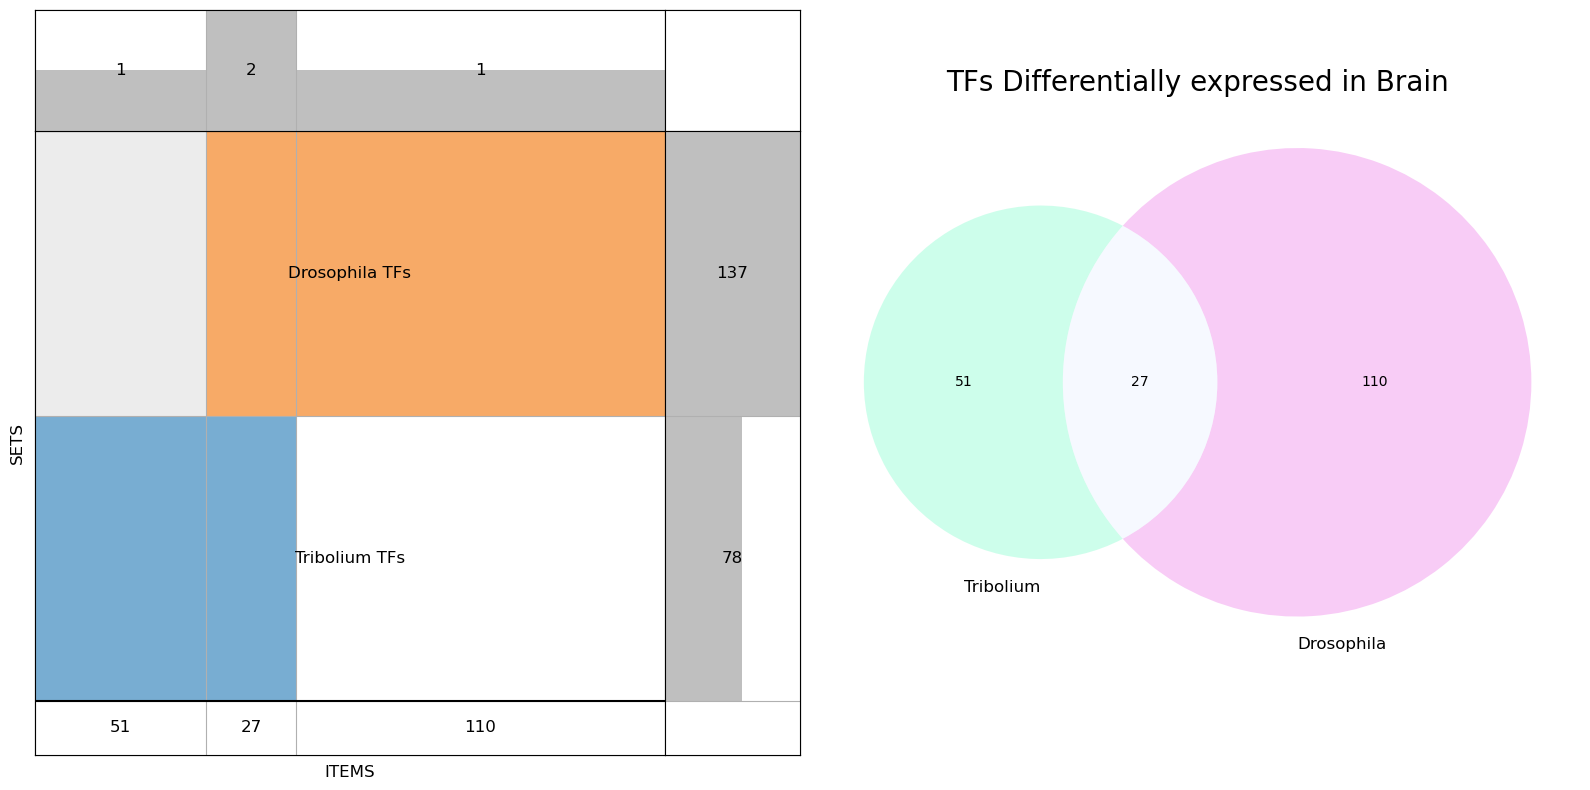

In [10]:
###this are all the TFs DE in  the brain neuroblasts datasets
path_TFs= 'TFS_found/'
droso_TF_found= pd.read_csv(f'{path_TFs}Drosophila/4_TFs_including_Hox_DE_ordered_as_inthe_heatmapplot_droso.csv')
tribo_TF_found= pd.read_csv(f'{path_TFs}Tribolium/4_TFs_including_Hox_DE_ordered_as_inthe_heatmapplot_tribolium.csv')

file1=tribo_TF_found[tribo_TF_found['Nbs_type'] == 'brain']
file2=droso_TF_found[droso_TF_found['Nbs_type'] == 'brain']

cerating_plots (file1= file1['gene_names'], 
                file2= file2['gene_symbol'],
                title= 'TFs Differentially expressed in Brain',
                savefig= 'TF_supervenn_brain_TFs_DE.pdf')

In [11]:
tf_lists = get_TF_lists(file1=file1['gene_names'], file2=file2['gene_symbol'])
print("Shared TFs:", tf_lists['len_shared_TFs'], tf_lists['shared_TFs'])
print("Tribolium only TFs:", tf_lists['len_tribo_only_TFs'], tf_lists['tribo_only_TFs'])
print("Drosophila only TFs:", tf_lists['len_droso_only_TFs'], tf_lists['droso_only_TFs'])

Shared TFs: 27 ['CG5516', 'D', 'Dll', 'Fer1', 'Hmx', 'Optix', 'Phf5a', 'Rx', 'TfAP-2', 'ac', 'ase', 'bi', 'croc', 'dac', 'disco', 'dmrt99B', 'erm', 'fd102C', 'fkh', 'hbn', 'oc', 'run', 'scro', 'tll', 'toy', 'tup', 'wor']
Tribolium only TFs: 51 ['APP-BP1', 'Arl2', 'Awh', 'CG10336', 'CG32532', 'Cox10', 'E2f2', 'Ets96B', 'Hesr', 'Hey', 'His2Av', 'Hr51', 'Hsf', 'MEP-1', 'Maf-S', 'Pep', 'Pfdn2', 'Polr2J', 'Polr2K', 'Polr2L', 'Prdm13', 'Rfx', 'Slip1', 'Snr1', 'Sox15', 'Sox21b', 'TC000383', 'TC004945', 'TC005398', 'TC006580', 'TC015373', 'TC031421', 'TC032655', 'TC032830', 'TC034050', 'Xbp1', 'acj6', 'dpn', 'dsf', 'dve', 'esc', 'fd59A', 'gcm', 'hry', 'ind', 'mRpS26', 'pan', 'prd', 'pros', 'prtp', 'ss']
Drosophila only TFs: 110 ['ADD1', 'Alh', 'Arc1', 'Axud1', 'B-H1', 'Bap111', 'Brf', 'CG10492', 'CG11696', 'CG11723', 'CG11788', 'CG12253', 'CG12299', 'CG12708', 'CG12942', 'CG15141', 'CG15435', 'CG15646', 'CG15696', 'CG16815', 'CG17359', 'CG18004', 'CG30460', 'CG34031', 'CG3847', 'CG4282', 'CG57

In [12]:
def tfs_classification (data= tribo_TF, savefig= 'lollipop', color= 'steelblue', threshold=2):
    databases = ['Pfam', 'PANTHER'] 
    threshold = threshold  # group categories with values <2 genes into 'Others'

    for db in databases:
        data[db] = data[db].fillna("Unknown")

    # --- Figure setup ---
    fig, axes = plt.subplots(1, 2, figsize=(16, 10)) 

    for ax, db in zip(axes, databases):
        counts = data[db].value_counts()

        # Group low-count categories into 'Others'
        counts_grouped = counts.copy()
        counts_grouped[counts_grouped <= threshold] = 0
        others_count = counts[counts <= threshold].sum()
        
        if others_count > 0:
            counts_grouped = counts_grouped[counts_grouped > 0]
            counts_grouped["Others"] = others_count

        counts_grouped = counts_grouped.sort_values(ascending=True)
        ax.hlines(y=counts_grouped.index, xmin=0, xmax=counts_grouped.values,
                color='lightsteelblue', linewidth=2)
        ax.plot(counts_grouped.values, counts_grouped.index, "o", color= color, markersize=8)

        for x, y in zip(counts_grouped.values, counts_grouped.index):
            ax.text(x + 0.2, y, str(x), va='center', fontsize=7, color='black')

        ax.set_xlabel("Number of Genes", fontsize=8)
        ax.set_ylabel(f"{db} Category", fontsize=8)
        ax.set_title(f"{db} Categories", fontsize=12)

    plt.tight_layout()
    plt.savefig(savefig, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()
    

#        set_colors=("#5CFEBD", "#E956E2"),


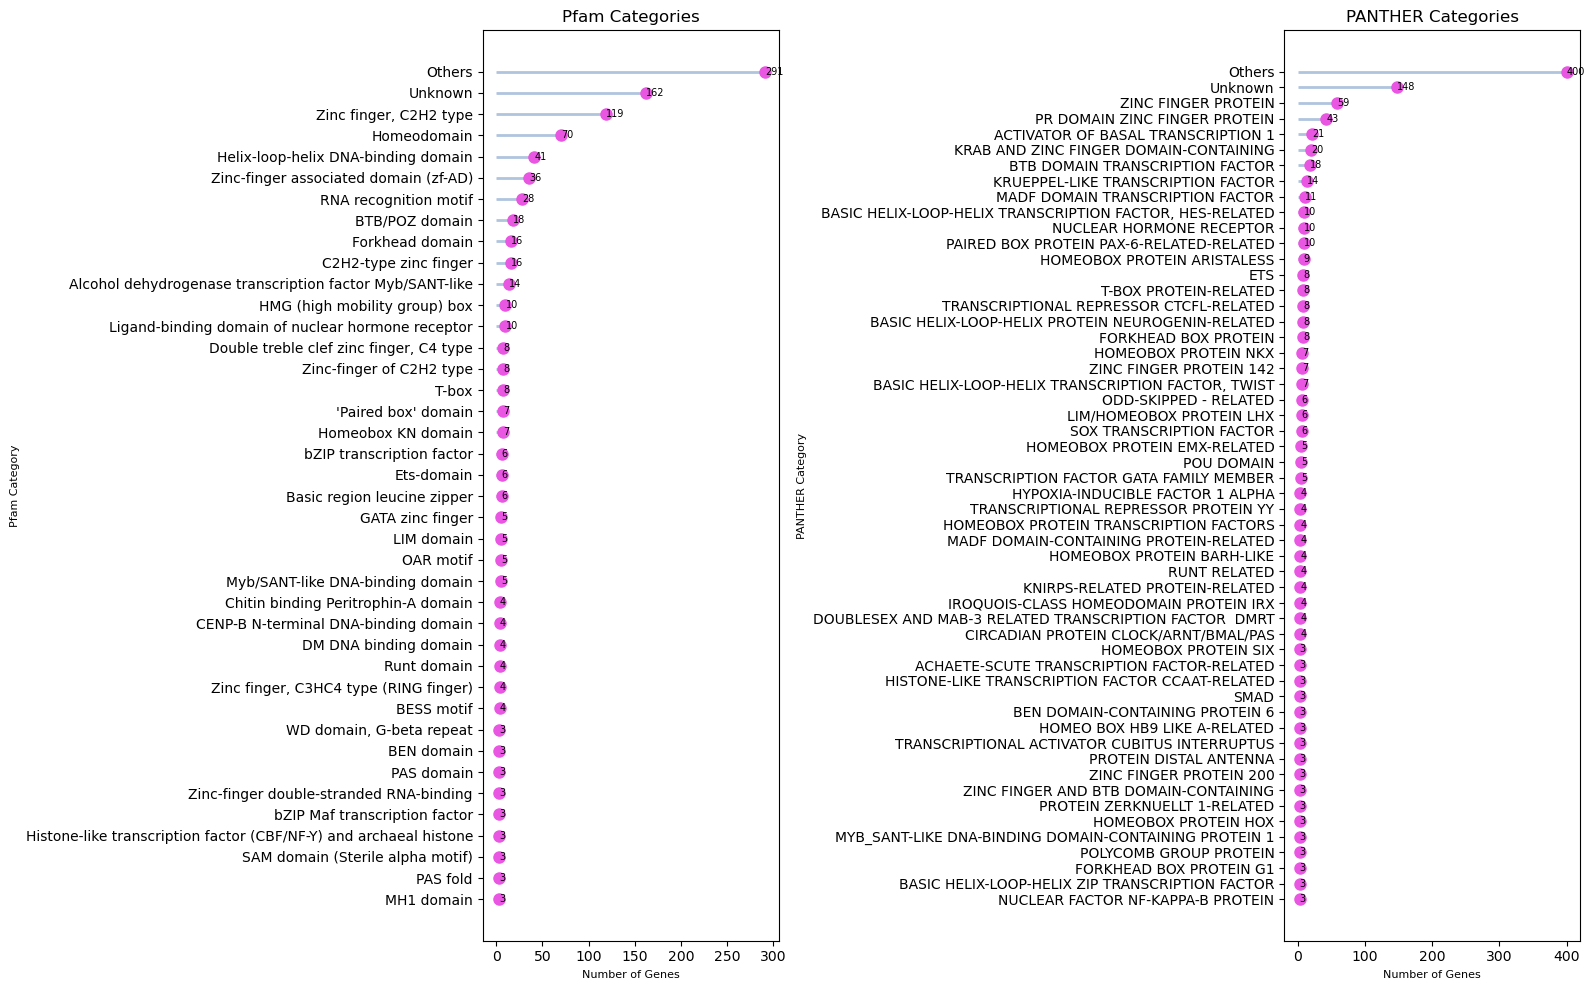

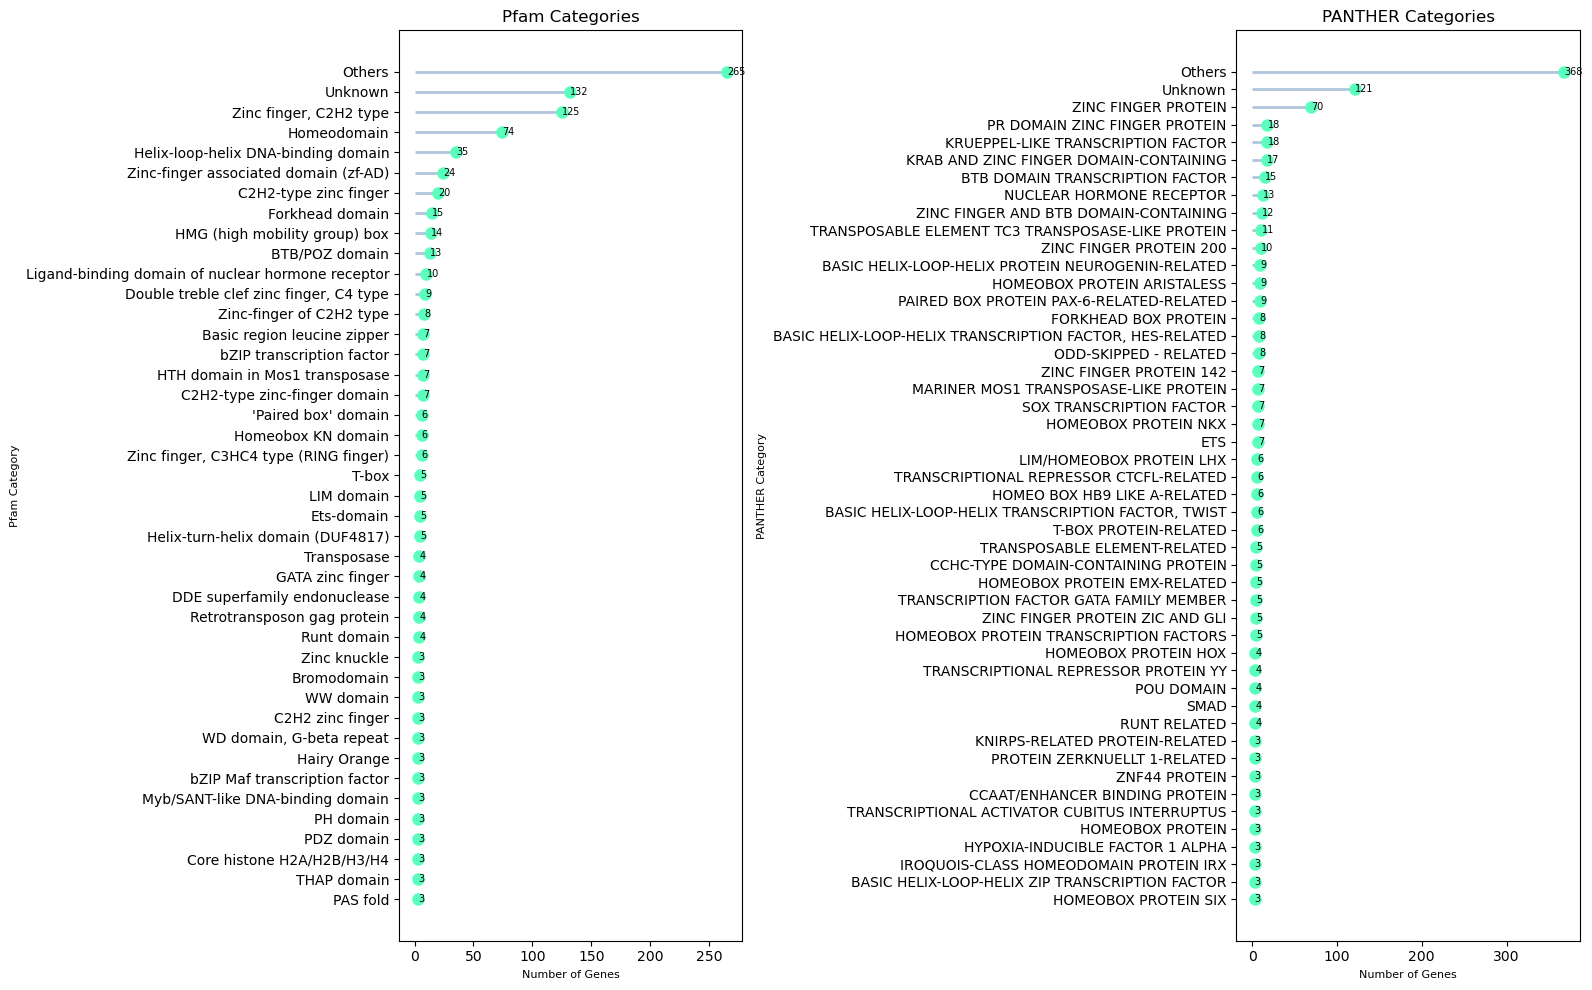

In [13]:
###this are the original list of TFs predicted
path_TFs= 'TF_predicted/'
droso_TF= pd.read_csv(f'{path_TFs}droso_output_true_annotated.csv', )
tribo_TF= pd.read_csv(f'{path_TFs}tribolium_output_true_annotated.csv', sep='\t',)

#Plot of TFs for drosophila
tfs_classification (droso_TF, color= "#E956E2",savefig='ALL_TFs_classification_drosophila.pdf')
#Plot of TFs for Tribolium
tfs_classification (tribo_TF, color= "#5CFEBD", savefig='ALL_TFs_classification_tribolium.pdf')


In [14]:
###this are all the TFs DE in  the VNC neuroblasts datasets

path_TFs= 'TFS_found/'
droso_TF_found= pd.read_csv(f'{path_TFs}Drosophila/4_TFs_including_Hox_DE_ordered_as_inthe_heatmapplot_droso.csv')
tribo_TF_found= pd.read_csv(f'{path_TFs}Tribolium/4_TFs_including_Hox_DE_ordered_as_inthe_heatmapplot_tribolium.csv')


file1=tribo_TF_found[tribo_TF_found['Nbs_type'] == 'VNC']
file1= file1['gene_names']
file2=droso_TF_found[droso_TF_found['Nbs_type'] == 'VNC']
file2= file2['gene_symbol']




In [15]:
# Filtering to get data only on TFs in VNC NBs tribolium
filtered_tribolium_VNC = tribo_TF[tribo_TF['gene_symbol'].isin(file1)]
filtered_tribolium_VNC.reset_index()

# Filtering to get data only on TFs in VNC NBs drosophila
filtered_droso_VNC = droso_TF[droso_TF['gene_name'].isin(file2)]
filtered_droso_VNC.reset_index()

,index,gene_name,prediction,score,Pfam,PANTHER,SUPERFAMILY
0,28,CG32772,True,0.9045,"Zinc finger, C2H2 type",PR DOMAIN ZINC FINGER PROTEIN,beta-beta-alpha zinc fingers
1,39,cbt,True,0.9640,"Zinc finger, C2H2 type",KRUEPPEL-LIKE TRANSCRIPTION FACTOR,beta-beta-alpha zinc fingers
2,46,kni,True,0.9836,"Double treble clef zinc finger, C4 type",KNIRPS-RELATED PROTEIN-RELATED,Glucocorticoid receptor-like (DNA-binding domain)
3,49,Hr78,True,0.9916,"Double treble clef zinc finger, C4 type",NUCLEAR HORMONE RECEPTOR,Glucocorticoid receptor-like (DNA-binding domain)
4,55,eg,True,0.9634,"Double treble clef zinc finger, C4 type",KNIRPS-RELATED PROTEIN-RELATED,Glucocorticoid receptor-like (DNA-binding domain)
...,...,...,...,...,...,...,...
148,932,slp1,True,0.9867,Forkhead domain,FORKHEAD BOX PROTEIN G1,"""Winged helix"" DNA-binding domain"
149,933,slp2,True,0.9987,Forkhead domain,FORKHEAD BOX PROTEIN G1,"""Winged helix"" DNA-binding domain"
150,937,odd,True,0.9870,"Zinc finger, C2H2 type",ODD-SKIPPED - RELATED,beta-beta-alpha zinc fingers
151,938,sob,True,0.9948,"Zinc finger, C2H2 type",ODD-SKIPPED - RELATED,beta-beta-alpha zinc fingers


In [16]:
filtered_tribolium_VNC

,sequence_ID,prediction,score,gene_symbol,Pfam,PANTHER,SUPERFAMILY
0,TC011311,True,0.9994,exd,PBC domain,HOMEOBOX PROTEIN TRANSCRIPTION FACTORS,Homeodomain-like
7,TC000903,True,0.9820,Ubx,Homeodomain,HOMEOBOX PROTEIN HOX,Homeodomain-like
8,TC010992,True,0.9560,hkb,"Zinc finger, C2H2 type",KRUEPPEL-LIKE TRANSCRIPTION FACTOR,beta-beta-alpha zinc fingers
10,TC032035,True,0.6464,Mnt,Helix-loop-helix DNA-binding domain,"MAX DIMERIZATION, MAD","HLH, helix-loop-helix DNA-binding domain"
30,TC032893,True,0.9986,Cph,"Zinc finger, C2H2 type",B-CELL LYMPHOMA/LEUKEMIA 11,beta-beta-alpha zinc fingers
...,...,...,...,...,...,...,...
818,TC007014,True,0.9975,vnd,Homeodomain,HOMEOBOX PROTEIN NKX,Homeodomain-like
832,TC008629,True,0.9982,hth,Homeobox KN domain,HOMEOBOX PROTEIN TRANSCRIPTION FACTORS,Homeodomain-like
844,TC014200,True,0.9972,HGTX,Homeodomain,HOMEOBOX PROTEIN NKX,Homeodomain-like
863,TC014350,True,0.9906,vvl,Homeodomain,POU DOMAIN,lambda repressor-like DNA-binding domains


In [17]:
gene_list = file1.tolist()

# Find missing genes
missing_genes = [g for g in gene_list if g not in tribo_TF['gene_symbol'].values]

print("Missing genes:", missing_genes)
#print("Number of missing genes:", len(missing_genes))
extra_gens= ['OdsH', 'tin', 'mip130', 'eg', 'Eip74EF', 'nub', 'Clamp', 'CG12104', 'Mnt', 'Ciz1', 'CTCF', 'ems' ,'gsb-n', 'mirr']

# Filtering to get data only on TFs in VNC NBs tribolium
filtered_tribolium_VNC_2 = tribo_TF[tribo_TF['gene_symbol'].isin(extra_gens)]
filtered_tribolium_VNC_2.reset_index()

concatenated_df = pd.concat([filtered_tribolium_VNC, filtered_tribolium_VNC_2], axis=0, ignore_index=True)
filtered_tribolium_VNC= concatenated_df
filtered_tribolium_VNC

Missing genes: ['CG43088', 'Cp190', 'TC034116', 'TC005661', 'sqz', 'CG34367', 'hwt', 'su(sable)', 'Ets65A', 'E5', 'gsb', 'Gsb-n']


,sequence_ID,prediction,score,gene_symbol,Pfam,PANTHER,SUPERFAMILY
0,TC011311,True,0.9994,exd,PBC domain,HOMEOBOX PROTEIN TRANSCRIPTION FACTORS,Homeodomain-like
1,TC000903,True,0.9820,Ubx,Homeodomain,HOMEOBOX PROTEIN HOX,Homeodomain-like
2,TC010992,True,0.9560,hkb,"Zinc finger, C2H2 type",KRUEPPEL-LIKE TRANSCRIPTION FACTOR,beta-beta-alpha zinc fingers
3,TC032035,True,0.6464,Mnt,Helix-loop-helix DNA-binding domain,"MAX DIMERIZATION, MAD","HLH, helix-loop-helix DNA-binding domain"
4,TC032893,True,0.9986,Cph,"Zinc finger, C2H2 type",B-CELL LYMPHOMA/LEUKEMIA 11,beta-beta-alpha zinc fingers
...,...,...,...,...,...,...,...
86,TC002961,True,0.9879,CTCF,"Zinc finger, C2H2 type",ZINC FINGER PROTEIN ZIC AND GLI,beta-beta-alpha zinc fingers
87,TC003413,True,0.9808,eg,"Double treble clef zinc finger, C4 type",KNIRPS-RELATED PROTEIN-RELATED,Glucocorticoid receptor-like (DNA-binding domain)
88,TC032451,True,0.9992,mirr,Homeobox KN domain,IROQUOIS-CLASS HOMEODOMAIN PROTEIN IRX,Homeodomain-like
89,TC012723,True,0.8358,CG12104,HMG (high mobility group) box,AGAP000281-PA,HMG-box


/tmp/ipykernel_122141/1628106969.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[db] = data[db].fillna("Unknown")
/tmp/ipykernel_122141/1628106969.py:35: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


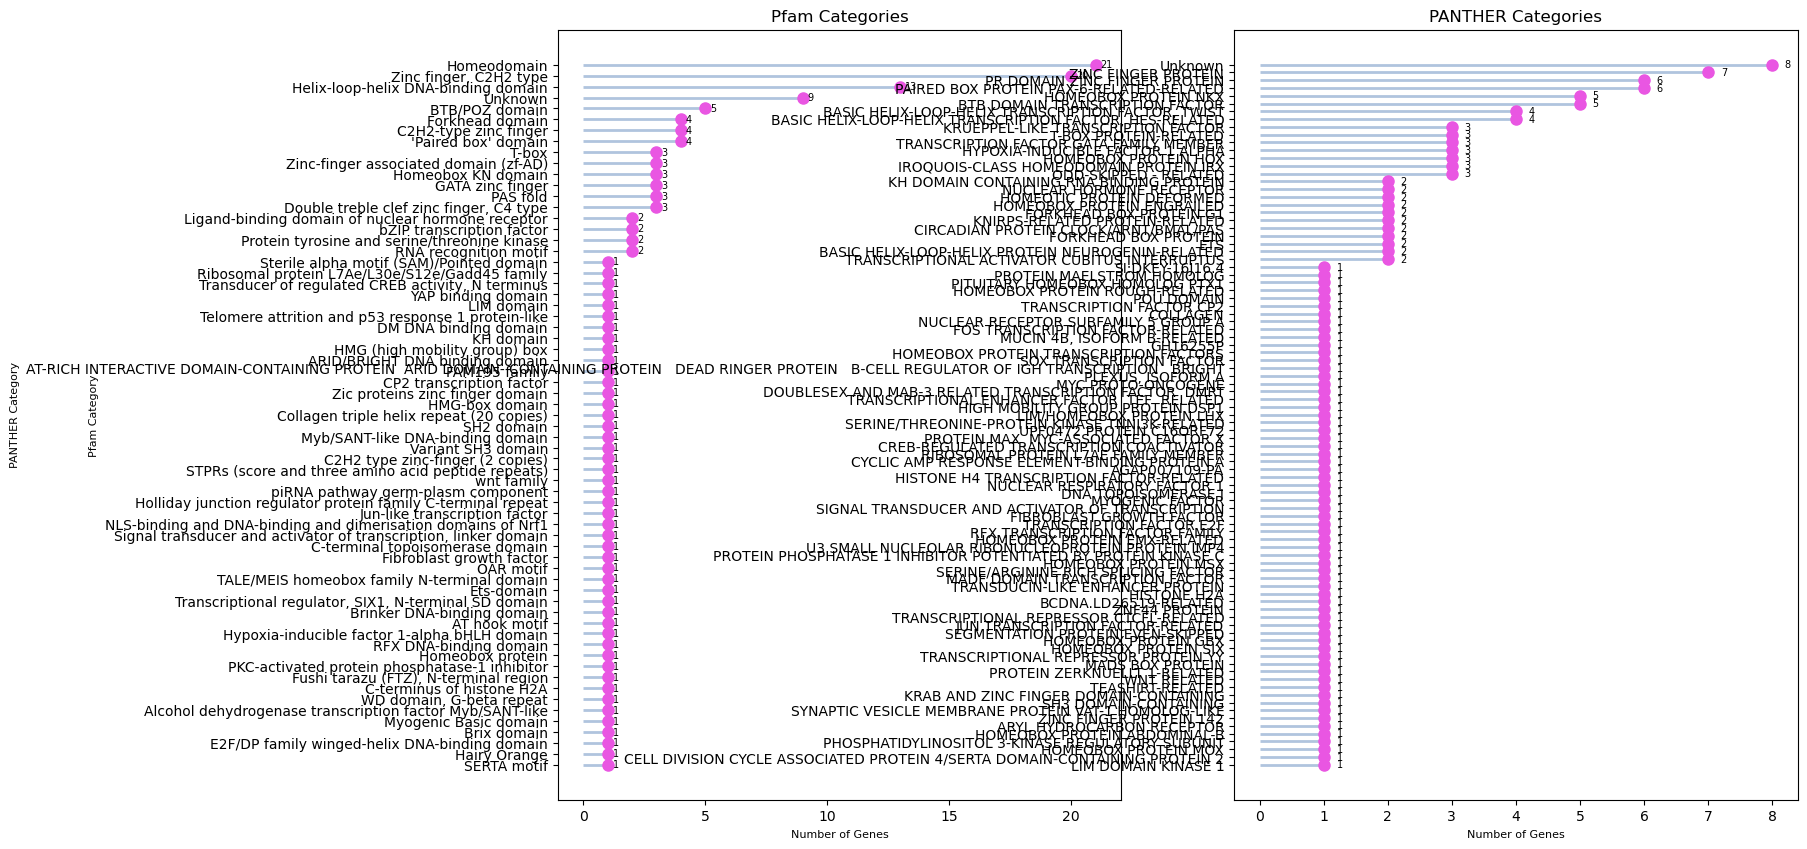

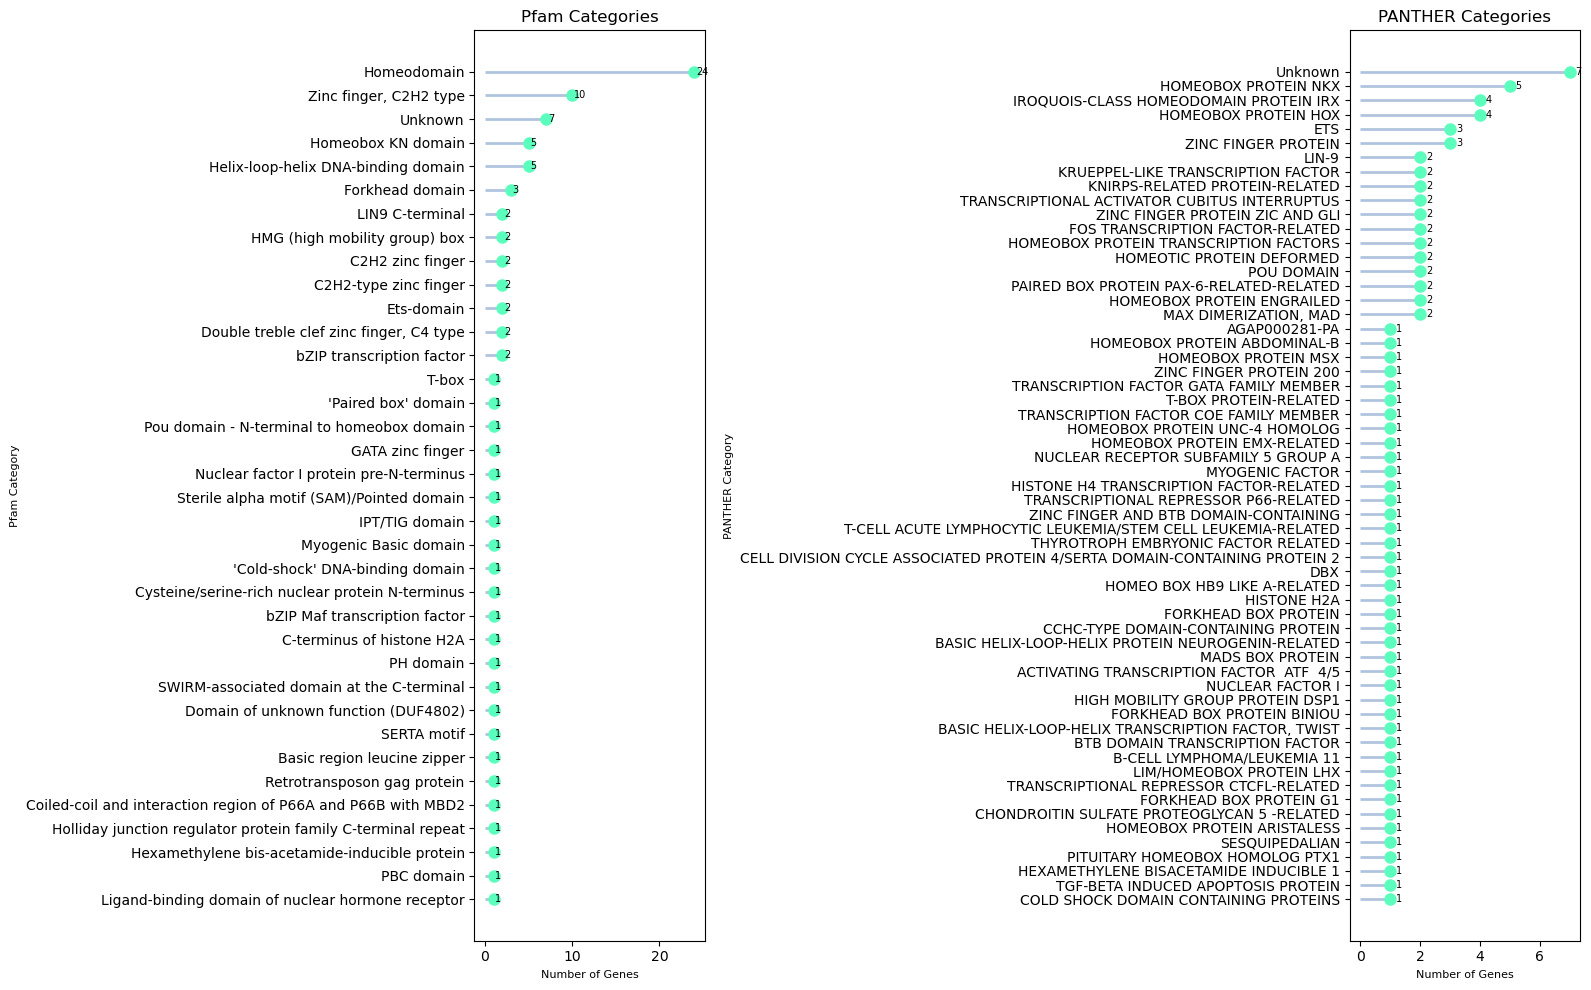

In [18]:
#Plot of TFs for drosophila
tfs_classification (filtered_droso_VNC, color= "#E956E2", savefig='TFs_classification_drosophila_VNC.pdf', threshold=0)
#Plot of TFs for Tribolium
tfs_classification (filtered_tribolium_VNC, color= "#5CFEBD",  savefig='TFs_classification_tribolium_VNC.pdf', threshold=0)

In [19]:
###this are all the TFs DE in  the VNC neuroblasts datasets
path_TFs= 'TFS_found/'
droso_TF_found= pd.read_csv(f'{path_TFs}Drosophila/4_TFs_including_Hox_DE_ordered_as_inthe_heatmapplot_droso.csv')
tribo_TF_found= pd.read_csv(f'{path_TFs}Tribolium/4_TFs_including_Hox_DE_ordered_as_inthe_heatmapplot_tribolium.csv')


file3=tribo_TF_found[tribo_TF_found['Nbs_type'] == 'brain']
file3= file3['gene_names']
file4=droso_TF_found[droso_TF_found['Nbs_type'] == 'brain']
file4= file4['gene_symbol']

In [20]:
# Filtering to get data only on TFs in VNC NBs tribolium
filtered_tribolium_brain = tribo_TF[tribo_TF['gene_symbol'].isin(file3)]
filtered_tribolium_brain.reset_index()

# Filtering to get data only on TFs in VNC NBs drosophila
filtered_droso_brain = droso_TF[droso_TF['gene_name'].isin(file4)]
filtered_droso_brain.reset_index()

,index,gene_name,prediction,score,Pfam,PANTHER,SUPERFAMILY
0,1,ac,True,0.9991,Helix-loop-helix DNA-binding domain,ACHAETE-SCUTE TRANSCRIPTION FACTOR-RELATED,"HLH, helix-loop-helix DNA-binding domain"
1,2,sc,True,0.9878,Helix-loop-helix DNA-binding domain,ACHAETE-SCUTE TRANSCRIPTION FACTOR-RELATED,"HLH, helix-loop-helix DNA-binding domain"
2,3,l(1)sc,True,0.9971,Helix-loop-helix DNA-binding domain,"BASIC HELIX-LOOP-HELIX TRANSCRIPTION FACTOR, T...","HLH, helix-loop-helix DNA-binding domain"
3,4,ase,True,0.9666,Helix-loop-helix DNA-binding domain,ACHAETE-SCUTE TRANSCRIPTION FACTOR-RELATED,"HLH, helix-loop-helix DNA-binding domain"
4,13,gt,True,0.9973,Basic region leucine zipper,THYROTROPH EMBRYONIC FACTOR RELATED,Leucine zipper domain
...,...,...,...,...,...,...,...
132,949,CG11723,True,0.5305,BESS motif,MADF DOMAIN TRANSCRIPTION FACTOR,NaN
133,950,erm,True,0.9890,C2H2-type zinc finger,ZINC FINGER PROTEIN,beta-beta-alpha zinc fingers
134,955,dac,Manually,1.0000,SKI/SNO/DAC Dachshund homology domain,DACHSHUND,Putative DNA-binding domain
135,956,scro,Manually,1.0000,Homeodomain,HOMEOBOX PROTEIN NKX,Homeodomain-like


In [21]:
gene_list = file3.tolist()

# Find missing genes
missing_genes = [g for g in gene_list if g not in tribo_TF['gene_symbol'].values]
missing_genes

print("Missing genes:", missing_genes)
#print("Number of missing genes:", len(missing_genes))
extra_gens= ['Ankrd11', 'Slip1', 'CG5516', 'esg', 'lz', 'maf-S', 'hry', 'CG32532']

# Filtering to get data only on TFs in VNC NBs tribolium
filtered_tribolium_brain_2 = tribo_TF[tribo_TF['gene_symbol'].isin(extra_gens)]
filtered_tribolium_brain_2.reset_index()

concatenated_df_brain = pd.concat([filtered_tribolium_brain, filtered_tribolium_brain_2], axis=0, ignore_index=True)
filtered_tribolium_brain= concatenated_df_brain
filtered_tribolium_brain

Missing genes: ['TC034050', 'Hsf', 'esc', 'wor', 'Maf-S']


,sequence_ID,prediction,score,gene_symbol,Pfam,PANTHER,SUPERFAMILY
0,TC015634,True,0.8021,Snr1,SNF5 / SMARCB1 / INI1,SNF5,NaN
1,TC032830,True,0.9200,TC032830,'Paired box' domain,PAIRED BOX PROTEIN PAX-6-RELATED-RELATED,Homeodomain-like
2,TC010041,True,0.8335,Arl2,ADP-ribosylation factor family,ADP-RIBOSYLATION FACTOR-LIKE PROTEIN 2-RELATED,P-loop containing nucleoside triphosphate hydr...
3,TC003419,True,0.8730,APP-BP1,ThiF family,UBIQUITIN-ACTIVATING ENZYME E1,Activating enzymes of the ubiquitin-like proteins
4,TC033450,True,0.9980,bi,Optomotor-blind protein N-terminal region,T-BOX PROTEIN-RELATED,p53-like transcription factors
...,...,...,...,...,...,...,...
76,TC007335,True,0.9979,CG32532,Homeodomain,HOMEOBOX PROTEIN ARISTALESS,Homeodomain-like
77,TC002375,True,0.5415,Ankrd11,Unknown,ANKYRIN REPEAT DOMAIN-CONTAINING PROTEIN 12,NaN
78,TC014168,True,0.7059,Slip1,PDZ domain,"PDZ DOMAIN CONTAINING RING FINGER PROTEIN 3, 4",PDZ domain-like
79,TC014474,True,0.9916,esg,"Zinc finger, C2H2 type",ZINC FINGER PROTEIN,beta-beta-alpha zinc fingers


/tmp/ipykernel_122141/1628106969.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[db] = data[db].fillna("Unknown")


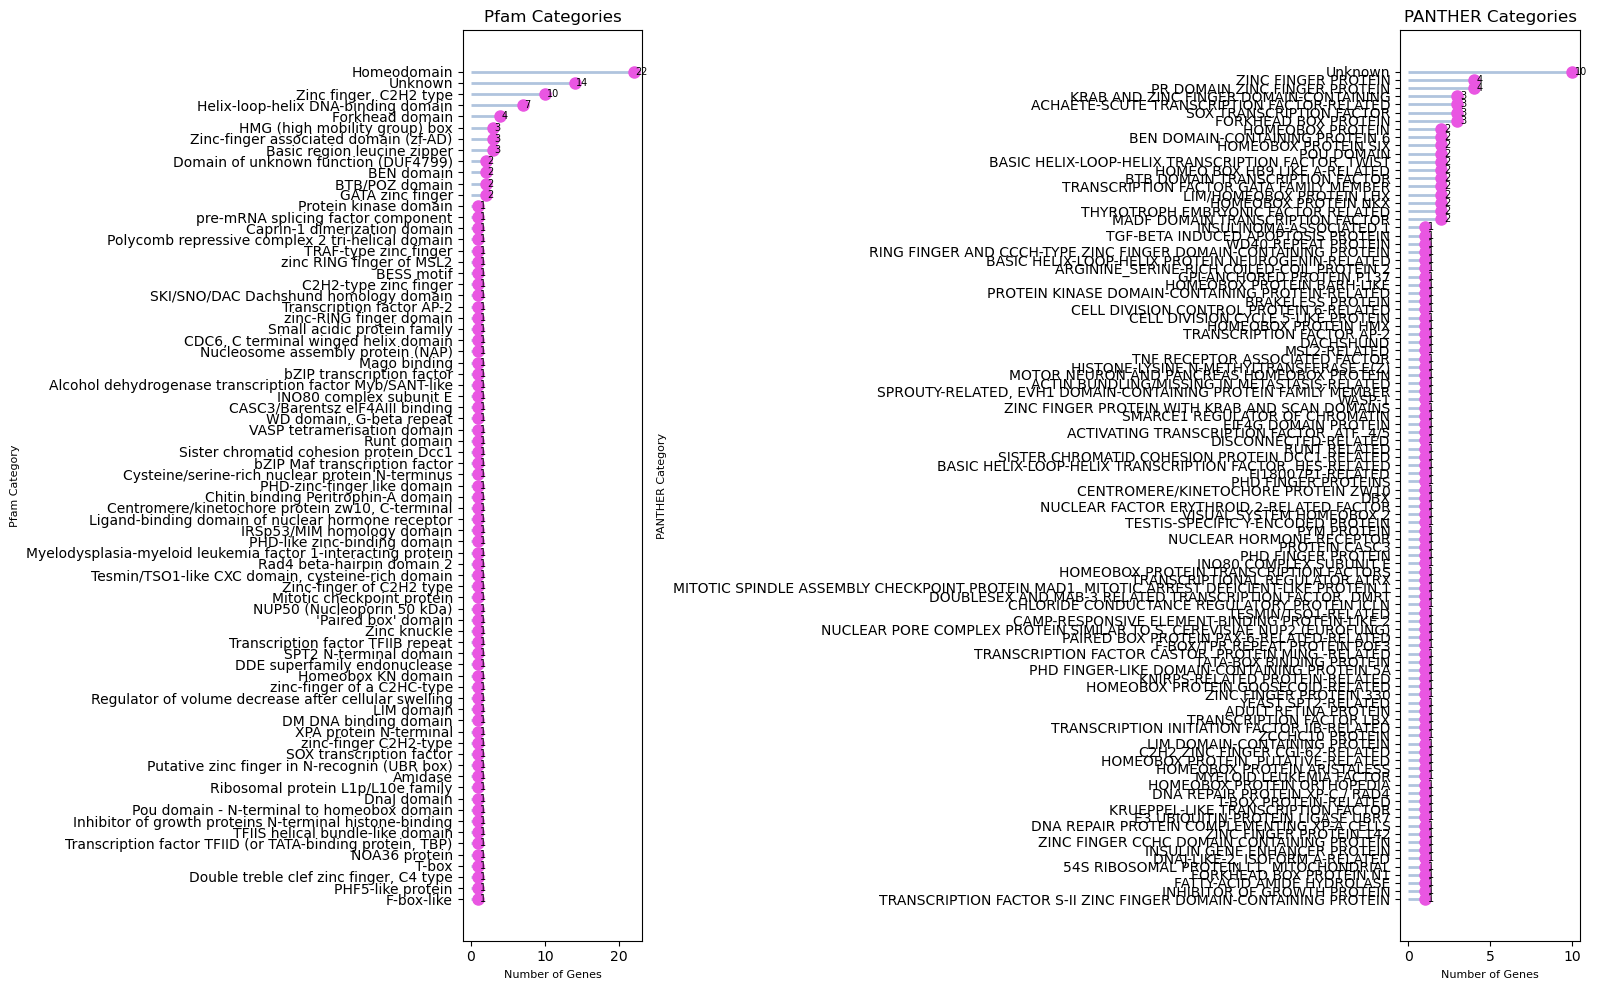

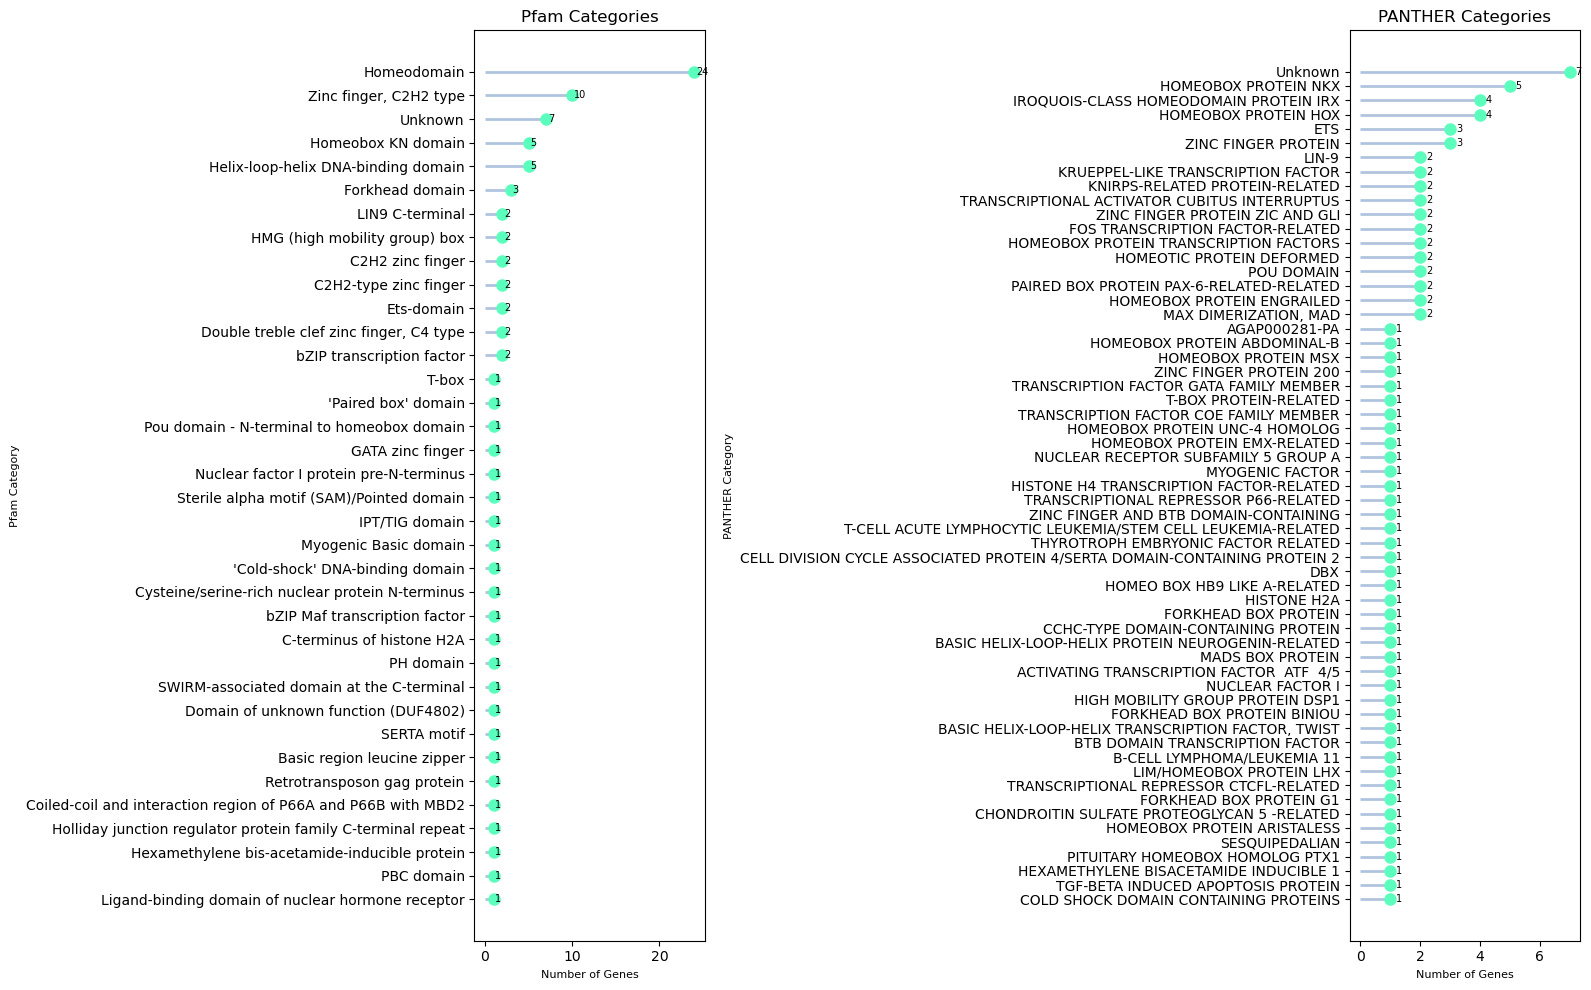

In [22]:
#Plot of TFs for drosophila
tfs_classification (filtered_droso_brain, color= "#E956E2", savefig='TFs_classification_drosophila_brain.pdf', threshold=0)
#Plot of TFs for Tribolium
tfs_classification (filtered_tribolium_VNC, color= "#5CFEBD",  savefig='TFs_classification_tribolium_brain.pdf', threshold=0)

In [23]:
#In this section i compared the results of the diferent replicates to see how variable they were

In [24]:
def cerating_plots_1(file1=None, 
                   file2=None,
                   file3=None,
                   title='TFs Differentially expressed (3 species)',
                   savefig='TF_supervenn_3_species.pdf'):

    # Input datasets
    tribo_TF_found = file1
    droso_TF_found = file2
    other_TF_found = file3

    # Convert to sets
    set_tribo = set(tribo_TF_found)
    set_droso = set(droso_TF_found)
    set_other = set(other_TF_found)

    # Put all sets in a list
    sets = [set_tribo, set_droso, set_other]
    set_annotations = ["TFs 5 replicates", "TFs 10 replicates", "TFs 15 replicates"]

    # ===========================
    # FIGURE WITH TWO SUBPLOTS
    # ===========================
    fig, axes = plt.subplots(1, 2, figsize=(18, 8))

    # -------- Supervenn plot --------
    plt.sca(axes[0])
    supervenn(
        sets,
        set_annotations=set_annotations,
        widths_minmax_ratio=0.05
    )
    plt.title("Supervenn Diagram (3 sets)", fontsize=18)

    # -------- Euler/Venn plot (Venn3) --------
    plt.sca(axes[1])
    venn3(
        [set_tribo, set_droso, set_other],
        set_labels=["5 replicates", "10 replicates", "15 replicates"],
        set_colors=("#5CFEBD", "#E956E2", "#6A8CFF"),
        alpha=0.30
    )
    plt.title(title, fontsize=18)

    plt.tight_layout()
    plt.savefig(savefig, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()


In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from supervenn import supervenn
import numpy as np

def cerating_plots_2(file1=None, 
                     file2=None,
                     file3=None,
                     title='TFs Differentially expressed (3 species)',
                     savefig='TF_supervenn_3_species.pdf', cmap='Greens'):

    # Input datasets
    tribo_TF_found = file1
    droso_TF_found = file2
    other_TF_found = file3

    # Convert to sets
    set_tribo = set(tribo_TF_found)
    set_droso = set(droso_TF_found)
    set_other = set(other_TF_found)

    sets = [set_tribo, set_droso, set_other]
    labels = ["5 replicates", "10 replicates", "15 replicates"]

    # ===========================
    # Compute Jaccard + intersection counts
    # ===========================
    jaccard_matrix = pd.DataFrame(index=labels, columns=labels, dtype=float)
    annotation_matrix = pd.DataFrame(index=labels, columns=labels, dtype=str)

    for i, s1 in enumerate(sets):
        for j, s2 in enumerate(sets):
            inter = len(s1 & s2)
            union = len(s1 | s2)
            jaccard = inter / union if union > 0 else 0.0

            # Store Jaccard as percentage (0-100) for color scale
            jaccard_matrix.iloc[i, j] = jaccard * 100

            # Create annotation: "85%\n(340)"
            annotation_matrix.iloc[i, j] = f"{jaccard*100:.0f}%\n({inter})"

    # ===========================
    # FIGURE WITH TWO SUBPLOTS
    # ===========================
    fig, axes = plt.subplots(1, 2, figsize=(18, 8))

    # -------- Supervenn plot --------
    plt.sca(axes[0])
    supervenn(
        sets,
        set_annotations=labels,
        widths_minmax_ratio=0.05
    )
    plt.title("Supervenn Diagram (3 sets)", fontsize=18)

    # -------- Jaccard Heatmap --------
    plt.sca(axes[1])
    sns.heatmap(
        jaccard_matrix,
        annot=annotation_matrix,
        fmt="",
        cmap=cmap, 
        vmin=0,
        vmax=100,  # color scale now matches percentage
        square=True,
        linewidths=0.5
    )
    plt.title(f"{title}\nJaccard Similarity Heatmap\n(% Jaccard with intersection size)", fontsize=16)

    plt.tight_layout()
    plt.savefig(savefig, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()


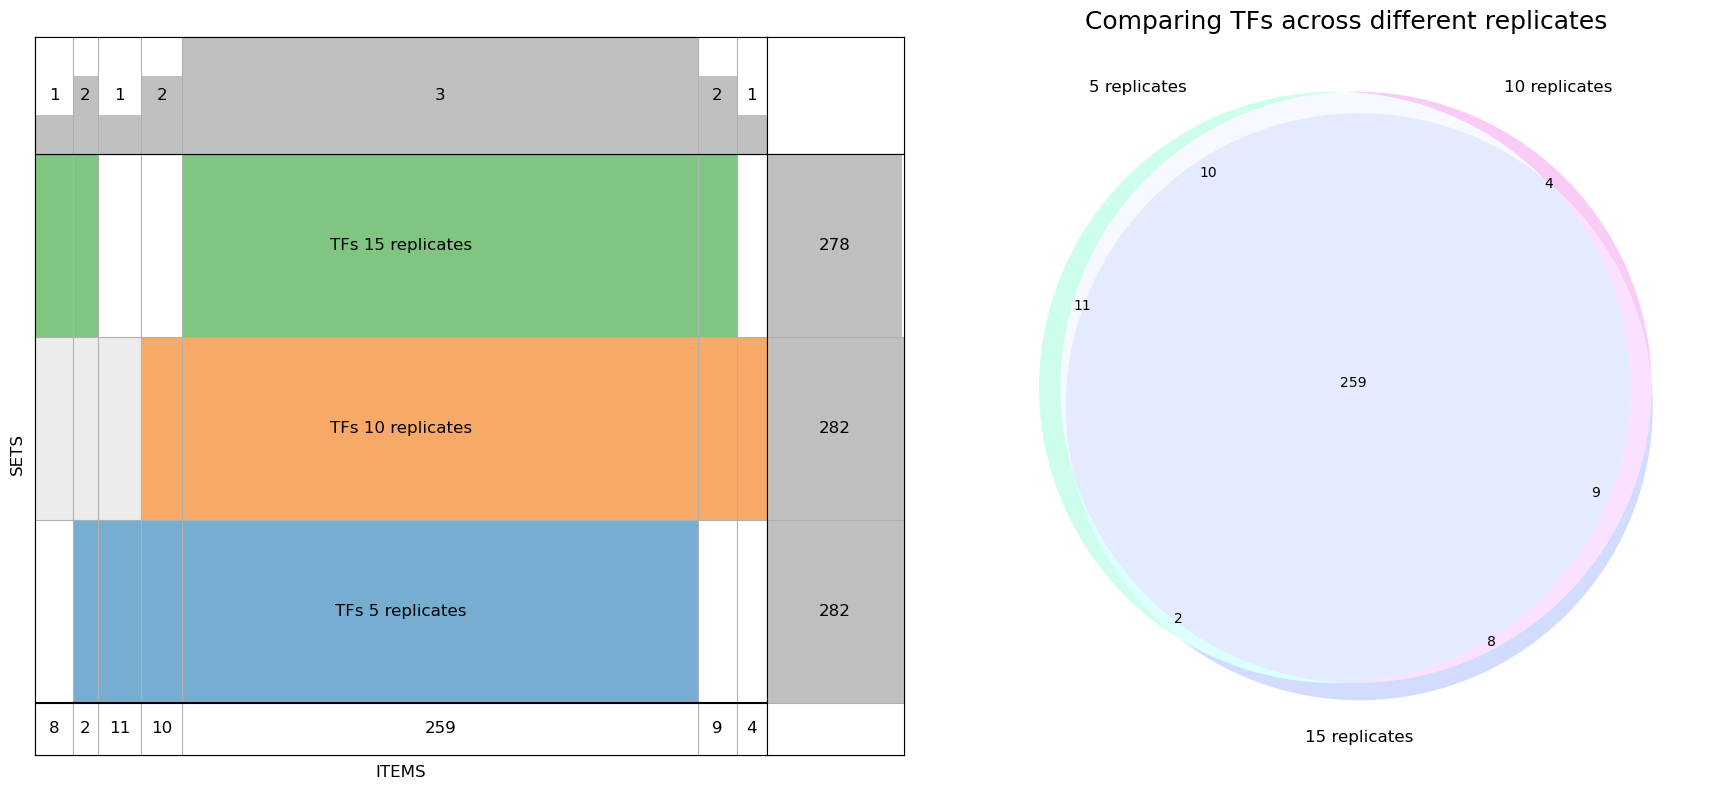

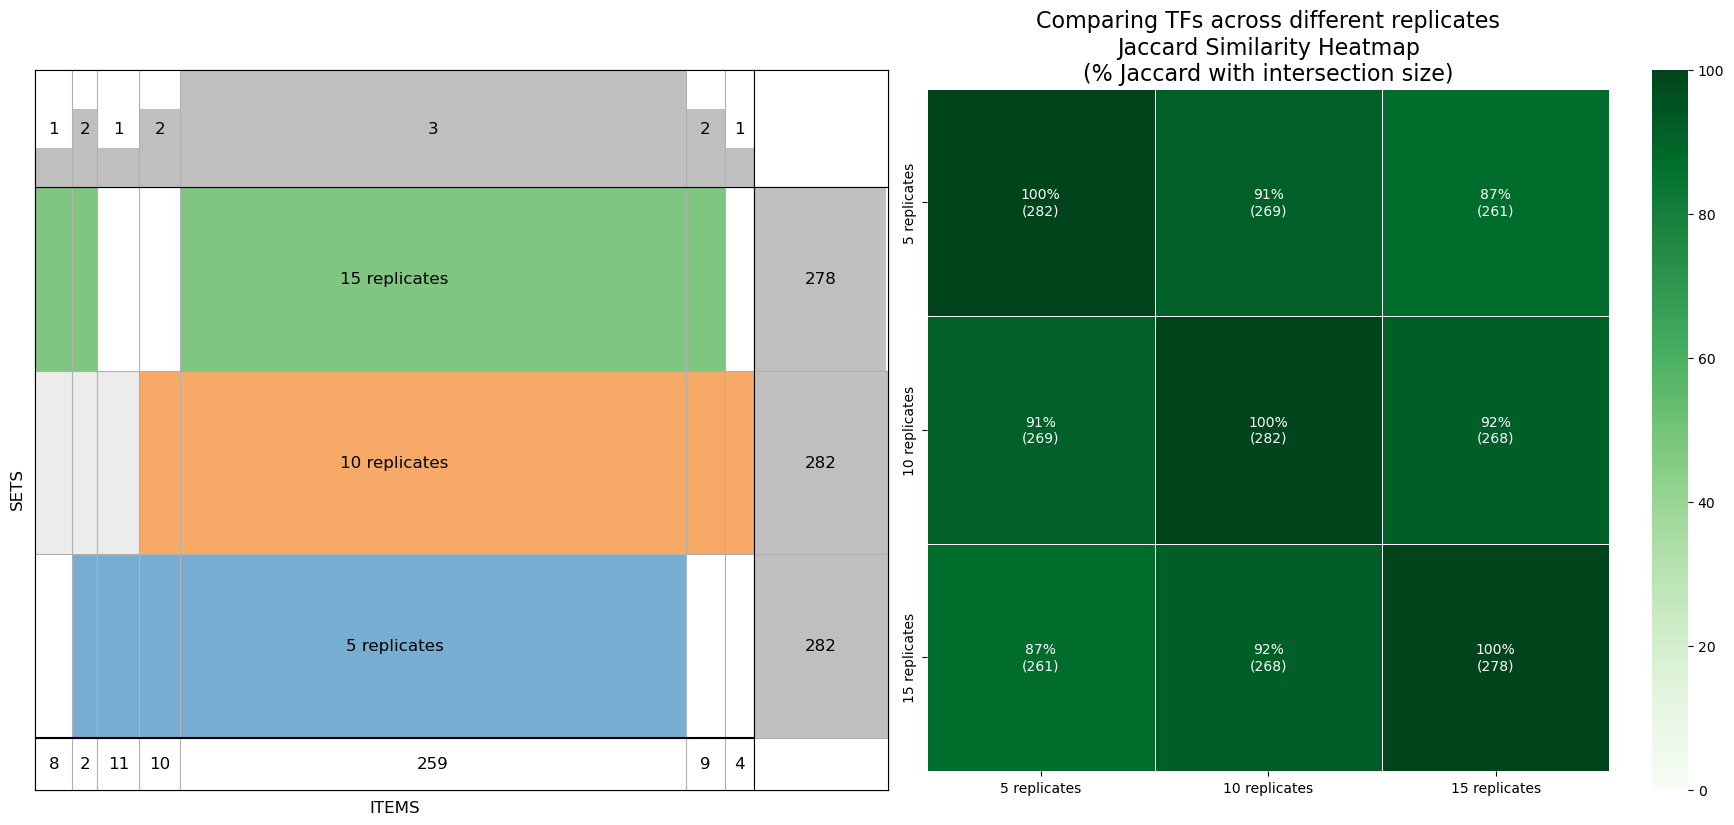

In [26]:
path_TFs= 'TFS_found/'
droso_TF_found_5_replicates= pd.read_csv(f'{path_TFs}Drosophila/4_TFs_without_Hox_DE_ordered_as_inthe_heatmapplot_droso5_replicates.csv')
droso_TF_found_10_replicates= pd.read_csv(f'{path_TFs}Drosophila/4_TFs_without_Hox_DE_ordered_as_inthe_heatmapplot_droso.csv')
droso_TF_found_15_replicates= pd.read_csv(f'{path_TFs}Drosophila/4_TFs_without_Hox_DE_ordered_as_inthe_heatmapplot_droso15_replicates.csv')


cerating_plots_1(
    file1=droso_TF_found_5_replicates['gene_symbol'],
    file2=droso_TF_found_10_replicates['gene_symbol'],
    file3=droso_TF_found_15_replicates['gene_symbol'],
    title="Comparing TFs across different replicates",
    savefig="TF_supervenn_comparing replicates_drosophila.pdf")


cerating_plots_2(
    file1=droso_TF_found_5_replicates['gene_symbol'],
    file2=droso_TF_found_10_replicates['gene_symbol'],
    file3=droso_TF_found_15_replicates['gene_symbol'],
    title="Comparing TFs across different replicates",
    savefig="TF_supervenn_comparing replicates_drosophila.pdf", )


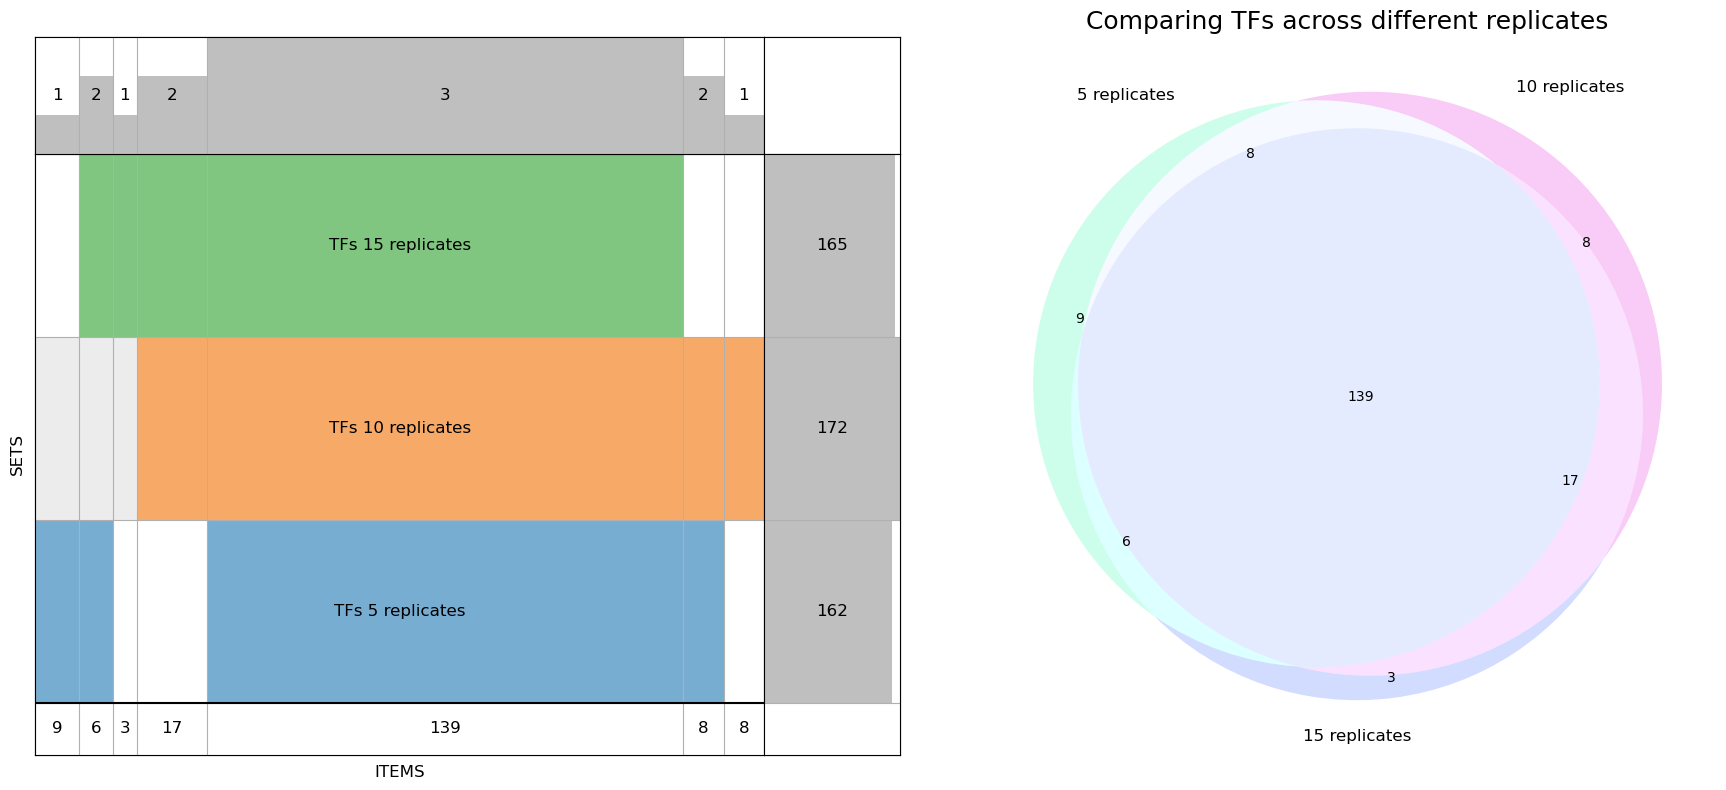

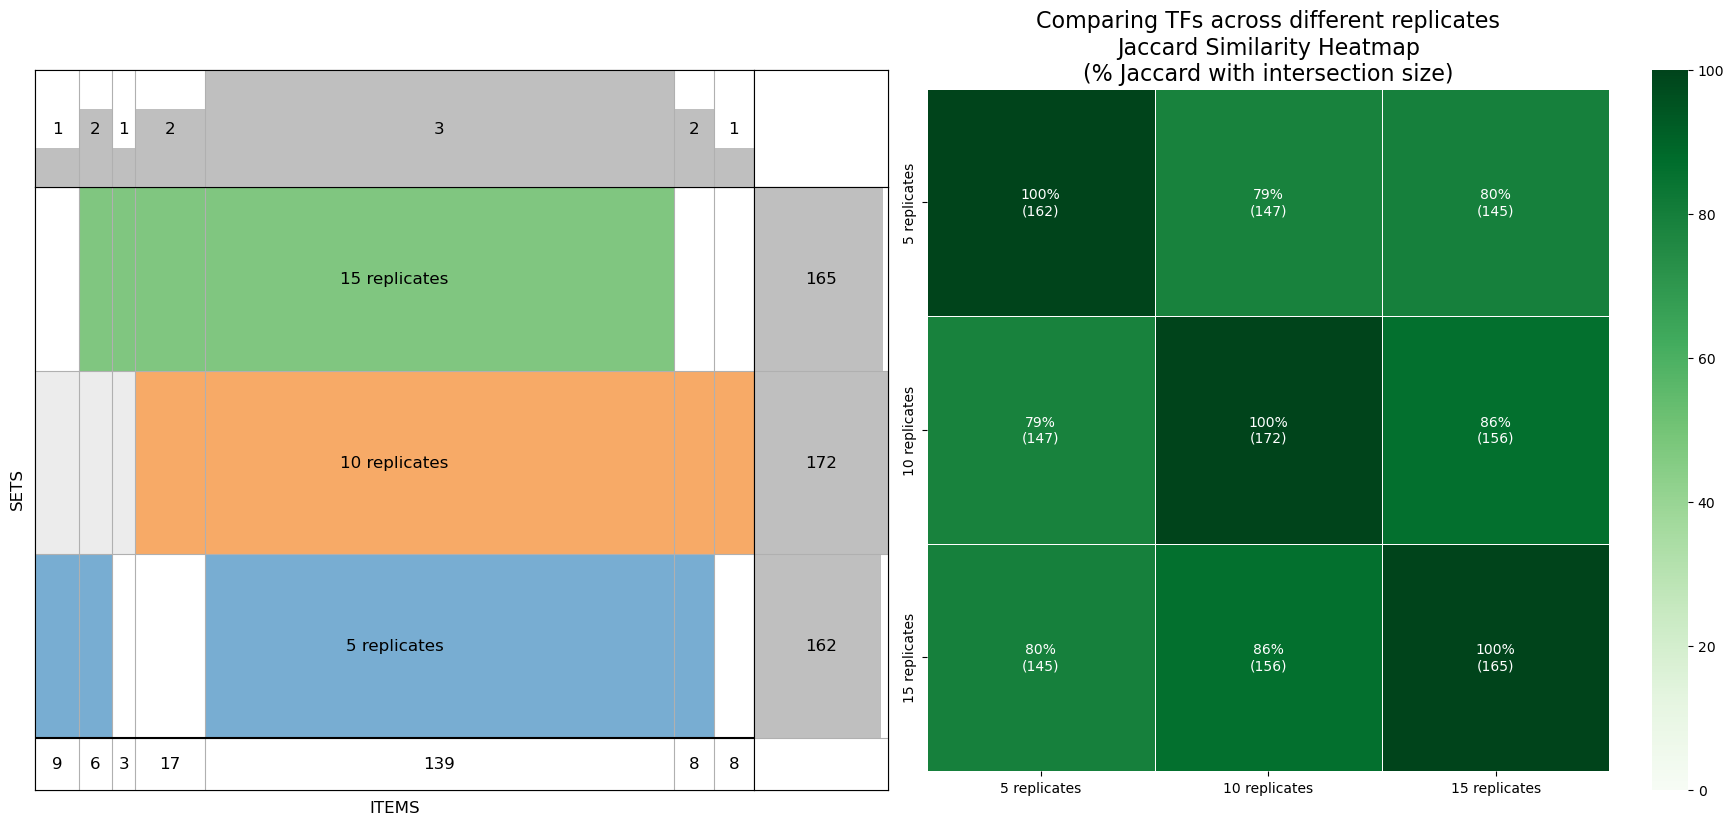

In [27]:
path_TFs= 'TFS_found/'
tribo_TF_found_5_replicates= pd.read_csv(f'{path_TFs}Tribolium/4_TFs_without_Hox_DE_ordered_as_inthe_heatmapplot_tribolium5_replicates.csv')
tribo_TF_found_10_replicates= pd.read_csv(f'{path_TFs}Tribolium/4_TFs_without_Hox_DE_ordered_as_inthe_heatmapplot_tribolium.csv')
tribo_TF_found_15_replicates= pd.read_csv(f'{path_TFs}Tribolium/4_TFs_without_Hox_DE_ordered_as_inthe_heatmapplot_tribolium15_replicates.csv')


cerating_plots_1(
    file1=tribo_TF_found_5_replicates['gene_names'],
    file2=tribo_TF_found_10_replicates['gene_names'], # droso_TF_found_10_replicates['gene_originals'],
    file3=tribo_TF_found_15_replicates['gene_names'],
    title="Comparing TFs across different replicates",
    savefig="TF_supervenn_comparing replicates_tribolium.pdf")

cerating_plots_2(
    file1=tribo_TF_found_5_replicates['gene_names'],
    file2=tribo_TF_found_10_replicates['gene_names'],  #droso_TF_found_10_replicates['gene_originals'],
    file3=tribo_TF_found_15_replicates['gene_names'],
    title="Comparing TFs across different replicates",
    savefig="TF_supervenn_comparing replicates_tribolium.pdf")